In [1]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install(c("BSgenome.Hsapiens.UCSC.hg38", "GenomicRanges", "TxDb.Hsapiens.UCSC.hg38.knownGene","org.Hs.eg.db"))

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org

Bioconductor version 3.16 (BiocManager 1.30.20), R 4.2.3 (2023-03-15)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'BSgenome.Hsapiens.UCSC.hg38' 'GenomicRanges'
  'TxDb.Hsapiens.UCSC.hg38.knownGene' 'org.Hs.eg.db'”
Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    boot, foreign, lattice, MASS, Matrix

Old packages: 'enrichplot', 'gargle', 'igraph', 'MPRAnalyze', 'processx', 'ps',
  'RcppArmadillo', 'scatterpie', 'zip'



In [17]:
#find one SNP's nearest gene
library(BSgenome.Hsapiens.UCSC.hg38)
library(GenomicRanges)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(TxDb.Hsapiens.UCSC.hg19.knownGene)
library(org.Hs.eg.db)
snp <- GRanges(seqnames = "chr17", ranges = IRanges(start = 5135359, end = 5135359+1))
txdb <- TxDb.Hsapiens.UCSC.hg19.knownGene


genes <- genes(txdb)
nearest_gene <- genes[nearest(snp, genes)]

# Assuming that your GRanges object is named 'nearest_gene'
nearest_gene$gene_symbol <- mapIds(org.Hs.eg.db, keys = nearest_gene$gene_id, column = "SYMBOL", keytype = "ENTREZID")

nearest_gene 


  403 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.

'select()' returned 1:1 mapping between keys and columns



GRanges object with 1 range and 2 metadata columns:
         seqnames          ranges strand |     gene_id gene_symbol
            <Rle>       <IRanges>  <Rle> | <character> <character>
  388325    chr17 5112216-5138155      - |      388325       SCIMP
  -------
  seqinfo: 93 sequences (1 circular) from hg19 genome

In [30]:
# Load the necessary packages
library(BSgenome.Hsapiens.UCSC.hg38)
library(GenomicRanges)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(TxDb.Hsapiens.UCSC.hg19.knownGene)
library(org.Hs.eg.db)

# Read the CSV file
snps <- read.csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor.csv')

# Split the SNP data by genome version
snps_list <- split(snps, snps$GENOME)

# Initialize a list to hold the results
results <- list()

# Process each subset of SNP data
for (genome_version in names(snps_list)) {
  # Get the subset of SNP data
  snps_subset <- snps_list[[genome_version]]
  
  # Create a GRanges object with the SNP data
  snp_granges <- GRanges(seqnames = snps_subset$CHROM, ranges = IRanges(start = snps_subset$SNPSTART, end = snps_subset$SNPEND))
  
  # Get the TxDb object for the genome version
  txdb_name <- ifelse(genome_version == "hg38", "TxDb.Hsapiens.UCSC.hg38.knownGene", "TxDb.Hsapiens.UCSC.hg19.knownGene")
  txdb <- eval(parse(text = txdb_name))
  
  # Get the gene locations
  genes <- genes(txdb)
  
  # Find the nearest genes for each SNP
  nearest_genes <- genes[nearest(snp_granges, genes)]
  
  # Map the gene IDs to gene symbols
  nearest_genes$gene_symbol <- mapIds(org.Hs.eg.db, keys = nearest_genes$gene_id, column = "SYMBOL", keytype = "ENTREZID")
  
  # Add the gene symbols to the original data frame
  snps_subset$nearest_gene <- nearest_genes$gene_symbol
  
  # Add the results to the list
  results[[genome_version]] <- snps_subset
}

# Combine the results into a single data frame
snps_with_genes <- do.call(rbind, results)

write.csv(snps_with_genes, '/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName.csv', row.names = FALSE)

  403 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.

'select()' returned 1:1 mapping between keys and columns

  1662 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.

'select()' returned 1:1 mapping between keys and columns



In [15]:
# Load necessary libraries
library(GenomicFeatures)
library(org.Hs.eg.db)

# Load TxDb object
txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

# Specify the gene of interest
gene_symbol <- "USP6"  # replace this with your gene

# Convert gene symbol to Entrez gene ID
gene_id <- mapIds(org.Hs.eg.db, 
                  keys = gene_symbol, 
                  column = "ENTREZID", 
                  keytype = "SYMBOL", 
                  multiVals = "first")

# Use the select() function to query the TxDb object
gene_info <- select(txdb, 
                    keys = gene_id, 
                    keytype = "GENEID", 
                    columns = "GENEID")

# Check if the gene exists
if (nrow(gene_info) > 0) {
  print(paste("The gene", gene_symbol, "exists in the database."))
} else {
  print(paste("The gene", gene_symbol, "does not exist in the database."))
}


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



[1] "The gene USP6 exists in the database."


In [2]:
import pandas as pd
df = pd.read_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName.csv')
df = df.drop_duplicates(["CHROM","SNPSTART","SNPEND"])
df['nearest_gene'] = df['nearest_gene'].replace({'ZNF594-DT':'SCIMP',"HLA-DRB5":"HLA-DRB1"})
df.to_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv')


In [3]:
df

,SNP_CENTER,PEAK_CENTER,FILE,CHROM,RSID,SNPSTART,SNPEND,REF,ALT,Contributor,...,SUMMIT,SUMMITZEROBASED,SUMMITREFSEQ,SUMMITALTSEQ,SNPREFSEQ,SNPALTSEQ,SUMMIT_DEV,GENOME,INDEL,nearest_gene
0,0,1,EAS_center,chr11,rs10736700,60031398,60031399,T,C,Pfenning,...,525,60031453,cttacttgtattttaaaaacccaggcccagataactccaacactcg...,cttacttgtattttaaaaacccaggcccagataactccaacactcg...,gaagactgaagccgaagactgaacatcagagttatacatcttgaca...,gaagactgaagccgaagactgaacatcagagttatacatcttgaca...,-55,hg19,NaN,MS4A4A
1,0,1,EAS_center,chr11,rs10736701,60031475,60031476,C,T,Pfenning,...,525,60031453,cttacttgtattttaaaaacccaggcccagataactccaacactcg...,cttacttgtattttaaaaacccaggcccagataactccaacactcg...,aggcccagataactccaacactcggtttctcctatatctgacattt...,aggcccagataactccaacactcggtttctcctatatctgacattt...,22,hg19,NaN,MS4A4A
2,0,1,EAS_center,chr6,rs1004173,47445016,47445017,C,T,Pfenning,...,58,47445073,gacaagagactaaaggaatctgtgaaacagaatttatttgatgcct...,gacaagagactaaaggaatctgtgaaacagaatttatttgatgcct...,acaactcaaattatactttaaaaagaaaaaaagcaaattataaagt...,acaactcaaattatactttaaaaagaaaaaaagcaaattataaagt...,-57,hg19,NaN,CD2AP
4,0,1,EAS_center,chr17,rs1010322,47338082,47338083,C,G,Pfenning,...,723,47338155,gacagcttcagccgggcgtcccctcagctgccttagctggcgtctg...,gacagcttcagccgggcgtcccctcagctgccttagctggggtctg...,ccgacactcgctcactggggcgcgggcacttgagagtaggcaacct...,ccgacactcgctcactggggcgcgggcacttgagagtaggcaacct...,-73,hg19,NaN,FLJ40194
6,0,1,EAS_center,chr17,rs112502960,47439301,47439302,G,A,Pfenning,...,829,47439243,ctagcgcacgcagctgcctcggcgaagggttacgccggcccccgga...,ctagcgcacgcagctgcctcggcgaagggttacgccggcccccgga...,cccgcgggcggcggagaggaagggctgccgggggcgccgccgcggc...,cccgcgggcggcggagaggaagggctgccgggggcgccgccgcggc...,58,hg19,NaN,ZNF652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,0,1,Calvin_df_center,chr19,rs1968456,1063079,1063080,G,C,Pfenning,...,323,1063075,catgctggctccacccacaccatggccccgccccatactcatgctg...,catgctggctccacccacaccatggccccgccccatactcatgctg...,ctggctccacccacaccatggccccgccccatactcatgctggctc...,ctggctccacccacaccatggccccgccccatactcatgctggctc...,4,hg38,NaN,ABCA7
772,0,1,Calvin_df_center,chr4,rs10030602,112086885,112086886,G,A,Pfenning,...,250,112086918,cacctcgctcggagggtcctacgcccacggagtcctctcactgatt...,cacctcgctcggagggtcctacgcccacggagtcctctcactgatt...,ataaaaaacggcgcaccacgagattatatcccgcacctcgctcgga...,ataaaaaacggcgcaccacgagattatatcccgcacctcgctcgga...,-33,hg38,NaN,FAM241A
773,0,1,Calvin_df_center,chr19,rs28399594,44806714,44806715,G,T,Pfenning,...,250,44806768,tctccttcatacacatgccatagagttctcctccctcacccagaac...,tctccttcatacacatgccatagagttctcctccctcacccagaac...,agtttctgcaagtctgcaagggtccacggctgctgttttggtgttt...,agtttctgcaagtctgcaagggtccacggctgctgttttggtgttt...,-54,hg38,NaN,BCAM
774,1,1,Calvin_df_bound,chr15,rs11638244,58614951,58614952,A,T,Pfenning,...,250,58614860,tgcacctggaagcaaaaaaaaccaataatcaccattgtgaaaacac...,tgcacctggaagcaaaaaaaaccaataatcaccattgtgaaaacac...,accacaaagctgtacaatacaggccactgtgatatacaaatgagaa...,accacaaagctgtacaatacaggccactgtgatatacaaatgagaa...,91,hg38,NaN,ADAM10


Loading required package: GenomeInfoDb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: BSgenome

Loading required package: GenomicRanges

Loading required package: Biostrings

L

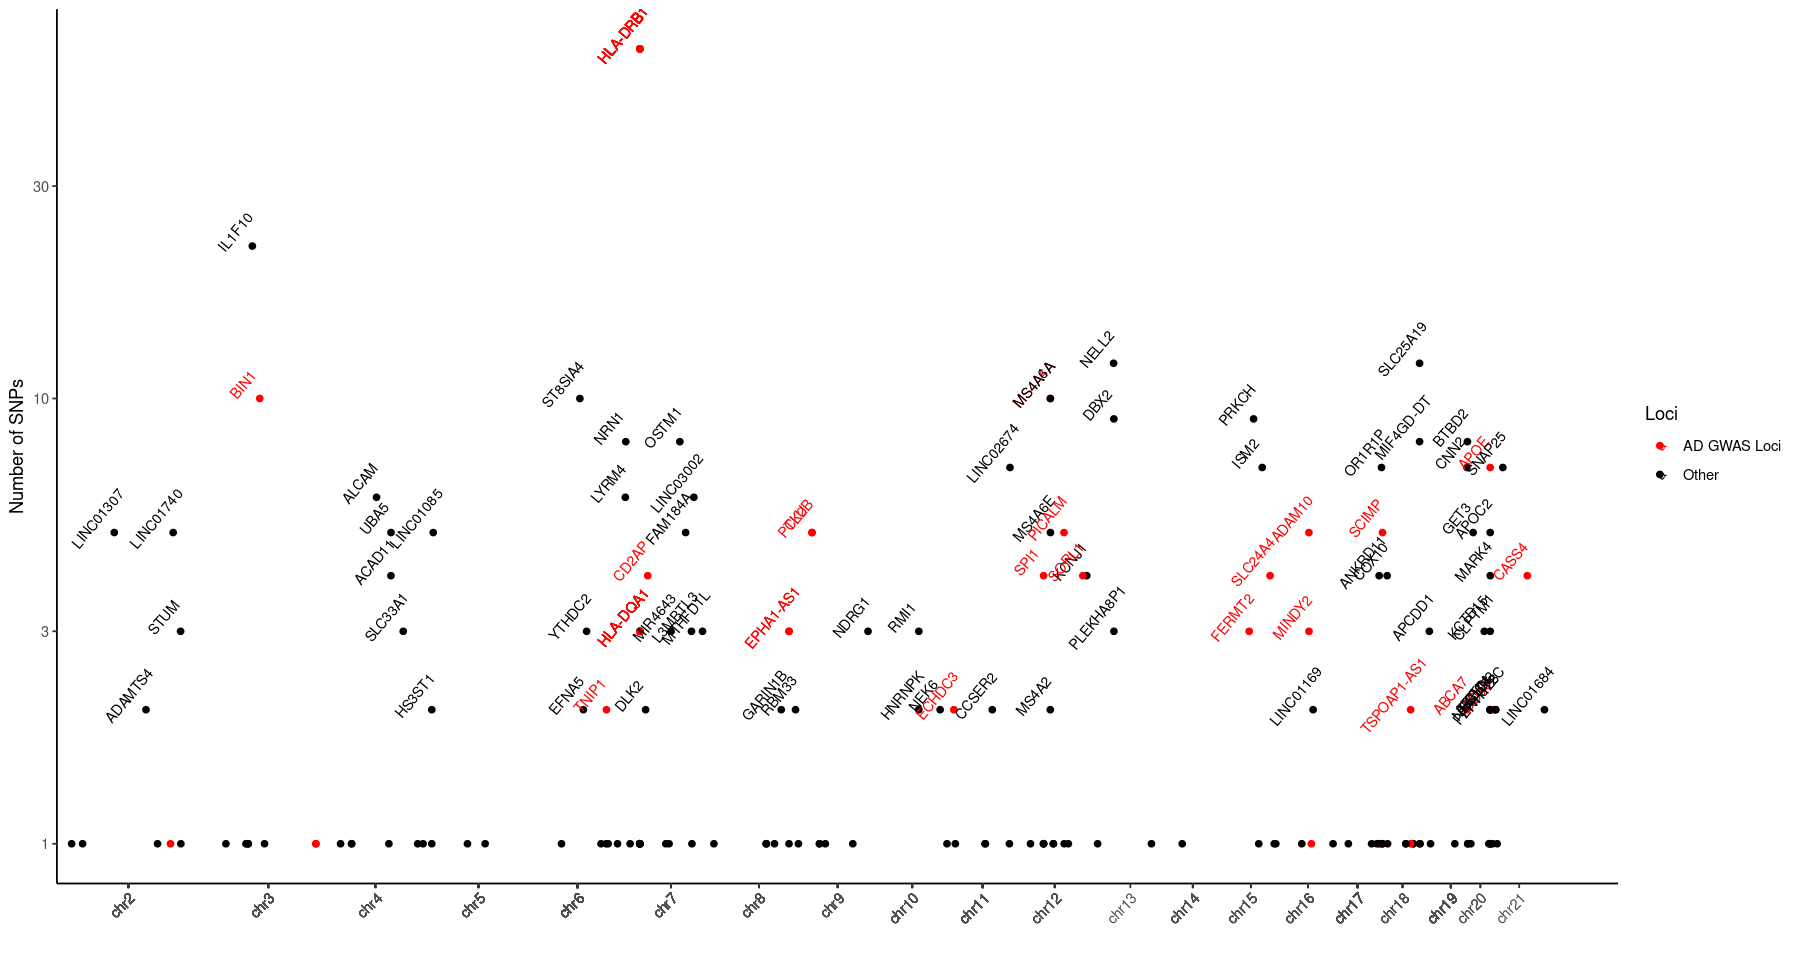

In [1]:
# Read the CSV file
snps <- read.csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv')
#snps<-snps[!snps$Contributor =="Win" | !snps$Contributor =="Dmitry",]


# Load necessary libraries
library(BSgenome.Hsapiens.UCSC.hg38)
library(tidyverse)


# Remove duplicates
snps <- snps[!duplicated(snps), ]

# Calculate the number of SNPs near each gene
snps <- snps %>%
  group_by(nearest_gene,CHROM) %>%
  summarise(
    COUNT = n(),
    .groups = "drop"
  )
  
#sort by chromosome
snps <- snps %>%
  arrange(CHROM)
  
library(biomaRt)

# Use the ensembl dataset
ensembl <- useMart("ensembl",dataset="hsapiens_gene_ensembl")

# Assuming the 'nearest_gene' column contains gene symbols:
gene_symbols <- unique(snps$nearest_gene)

# Get the gene positions
gene_positions <- getBM(attributes=c('hgnc_symbol', 'chromosome_name', 'start_position', 'end_position'),
                        filters = 'hgnc_symbol',
                        values = gene_symbols,
                        mart = ensembl)

# You may want to create a single "position" column
gene_positions$position <- paste(gene_positions$chromosome_name, gene_positions$start_position, gene_positions$end_position, sep=":")

# Merge 'snps' and 'gene_positions'
snps <- merge(snps, gene_positions, by.x = "nearest_gene", by.y = "hgnc_symbol", all.x = TRUE)

# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]

# Calculate the cumulative chromosome lengths
cumulative_lengths <- cumsum(as.numeric(chromosome_lengths))

# Create the continuous genome position
#snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM] - chromosome_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]

#sort by chromosome
snps <- snps %>%
  arrange(CHROM)

#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]
nm<- names(chromosome_lengths)
# Convert the chromosome lengths to numeric to avoid integer overflow
chromosome_lengths <- as.numeric(chromosome_lengths)

# Calculate the cumulative chromosome lengths
cumulative_lengths <- c(0, cumsum(chromosome_lengths)[-length(chromosome_lengths)])

# Convert the cumulative lengths to named vector
names(cumulative_lengths) <- nm
names(chromosome_lengths) <- nm
# Now the cumulative_lengths is in the same format as seqlengths(Hsapiens)

# Create the continuous genome position
snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]



# List of genes to highlight
highlight_genes <- unique(read.csv('/media/zihengc/T7 Shield/mpra3_lib_analysis/Find_nearest_gene/AD_GWAS_Gene_Wightman.csv')$Gene)
# Create a new variable for color
snps$Loci <- ifelse(snps$nearest_gene %in% highlight_genes, "AD GWAS Loci", "Other")

# Modify the plot code
p <- ggplot(snps, aes(x = genome_position, y = COUNT, label = nearest_gene, color = Loci)) +
  geom_point() +
  geom_text(data = subset(snps, COUNT > 1), vjust = -1.5, angle = 50, size = 3) +
  scale_y_continuous(trans = "log10") +
  scale_x_continuous(breaks = chromosome_midpoints, labels = names(chromosome_midpoints), expand = expansion(mult = c(0.01, 0.05))) + # expand x-axis
  scale_color_manual(values = c("AD GWAS Loci" = "red", "Other" = "black")) +
  labs(x = "", y = "Number of SNPs") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),plot.title = element_text(hjust = 0.5))#+ggtitle("Common Variants") 
# Increase the width of the plot window
options(repr.plot.width=15, repr.plot.height=8)

print(p)

Warning message:
“Removed 13 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values (`geom_text()`).”


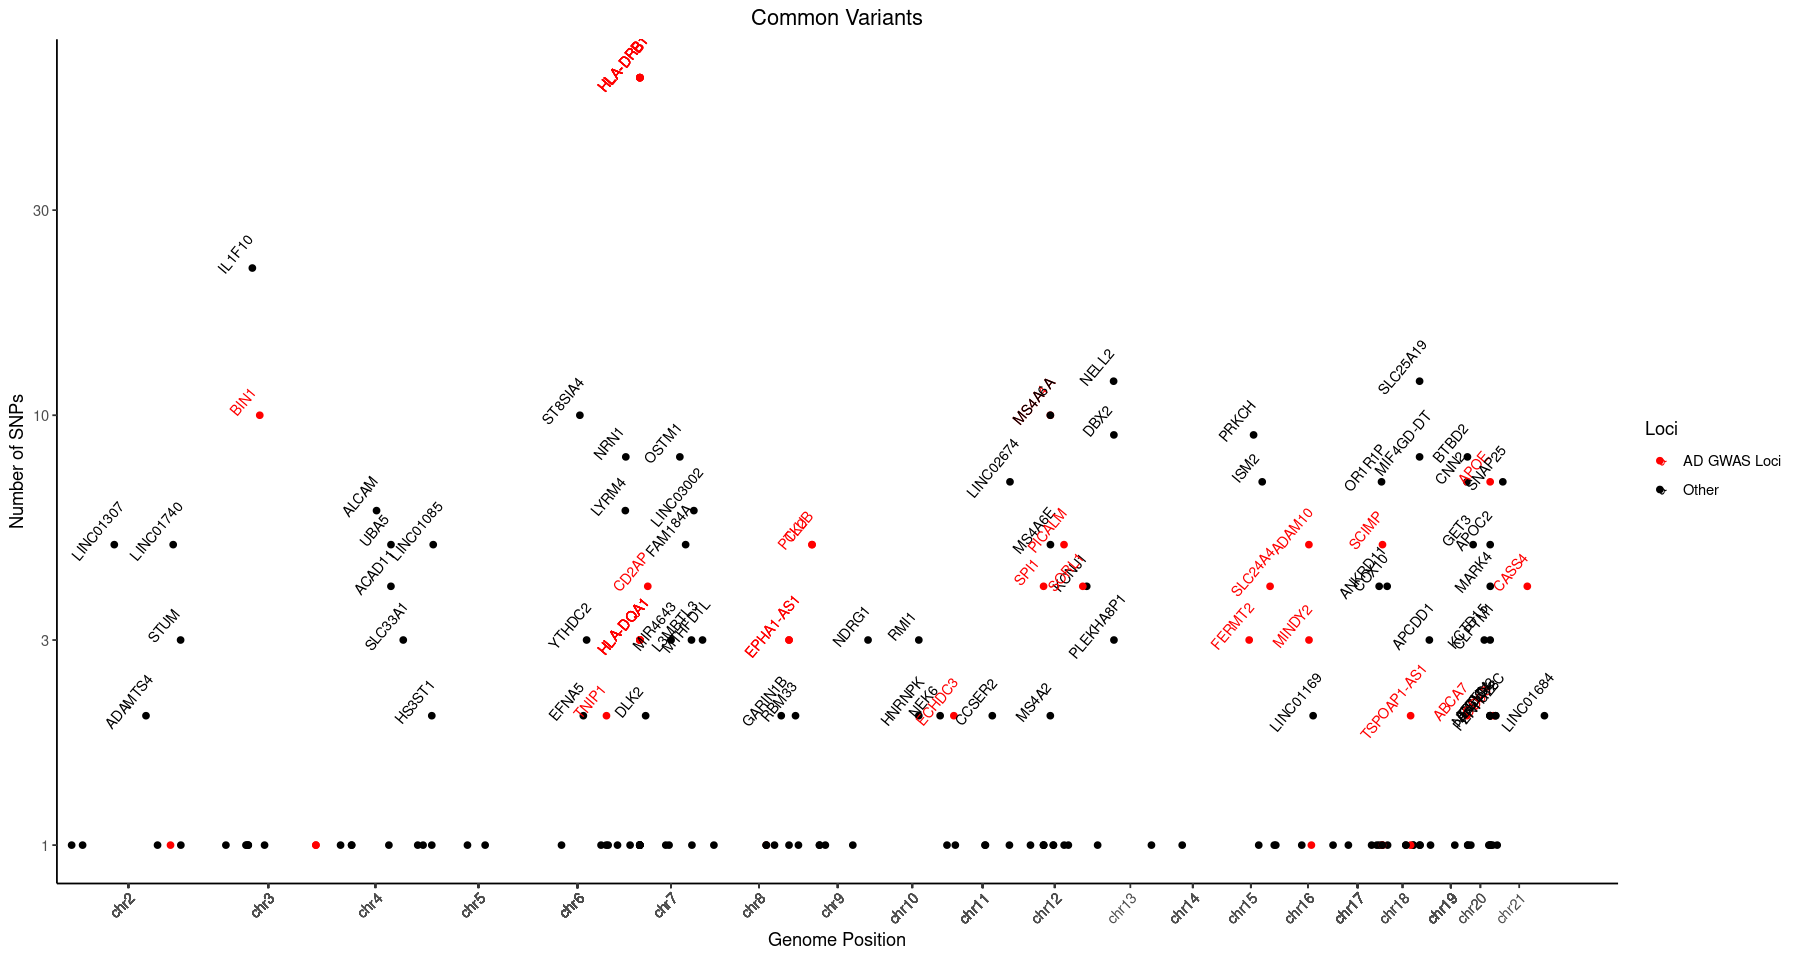

In [2]:
# Read the CSV file
snps <- read.csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv')
snps<-snps[!snps$Contributor =="Win" | !snps$Contributor =="Dmitry",]


# Load necessary libraries
library(BSgenome.Hsapiens.UCSC.hg38)
library(tidyverse)


# Remove duplicates
snps <- snps[!duplicated(snps), ]

# Calculate the number of SNPs near each gene
snps <- snps %>%
  group_by(nearest_gene,CHROM) %>%
  summarise(
    COUNT = n(),
    .groups = "drop"
  )
  
#sort by chromosome
snps <- snps %>%
  arrange(CHROM)
  
library(biomaRt)

# Use the ensembl dataset
ensembl <- useMart("ensembl",dataset="hsapiens_gene_ensembl")

# Assuming the 'nearest_gene' column contains gene symbols:
gene_symbols <- unique(snps$nearest_gene)

# Get the gene positions
gene_positions <- getBM(attributes=c('hgnc_symbol', 'chromosome_name', 'start_position', 'end_position'),
                        filters = 'hgnc_symbol',
                        values = gene_symbols,
                        mart = ensembl)

# You may want to create a single "position" column
gene_positions$position <- paste(gene_positions$chromosome_name, gene_positions$start_position, gene_positions$end_position, sep=":")

# Merge 'snps' and 'gene_positions'
snps <- merge(snps, gene_positions, by.x = "nearest_gene", by.y = "hgnc_symbol", all.x = TRUE)

# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]

# Calculate the cumulative chromosome lengths
cumulative_lengths <- cumsum(as.numeric(chromosome_lengths))

# Create the continuous genome position
#snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM] - chromosome_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]

#sort by chromosome
snps <- snps %>%
  arrange(CHROM)

#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]
nm<- names(chromosome_lengths)
# Convert the chromosome lengths to numeric to avoid integer overflow
chromosome_lengths <- as.numeric(chromosome_lengths)

# Calculate the cumulative chromosome lengths
cumulative_lengths <- c(0, cumsum(chromosome_lengths)[-length(chromosome_lengths)])

# Convert the cumulative lengths to named vector
names(cumulative_lengths) <- nm
names(chromosome_lengths) <- nm
# Now the cumulative_lengths is in the same format as seqlengths(Hsapiens)

# Create the continuous genome position
snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]



# List of genes to highlight
highlight_genes <- unique(read.csv('/media/zihengc/T7 Shield/mpra3_lib_analysis/Find_nearest_gene/AD_GWAS_Gene_Wightman.csv')$Gene)
# Create a new variable for color
snps$Loci <- ifelse(snps$nearest_gene %in% highlight_genes, "AD GWAS Loci", "Other")

# Modify the plot code
p <- ggplot(snps, aes(x = genome_position, y = COUNT, label = nearest_gene, color = Loci)) +
  geom_point() +
  geom_text(data = subset(snps, COUNT > 1), vjust = -1.5, angle = 50, size = 3) +
  scale_y_continuous(trans = "log10") +
  scale_x_continuous(breaks = chromosome_midpoints, labels = names(chromosome_midpoints), expand = expansion(mult = c(0.01, 0.05))) + # expand x-axis
  scale_color_manual(values = c("AD GWAS Loci" = "red", "Other" = "black")) +
  labs(x = "Genome Position", y = "Number of SNPs") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),plot.title = element_text(hjust = 0.5))+
  ggtitle("Common Variants") 
# Increase the width of the plot window
options(repr.plot.width=15, repr.plot.height=8)

print(p)

Warning message:
“Removed 11 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 7 rows containing missing values (`geom_text()`).”


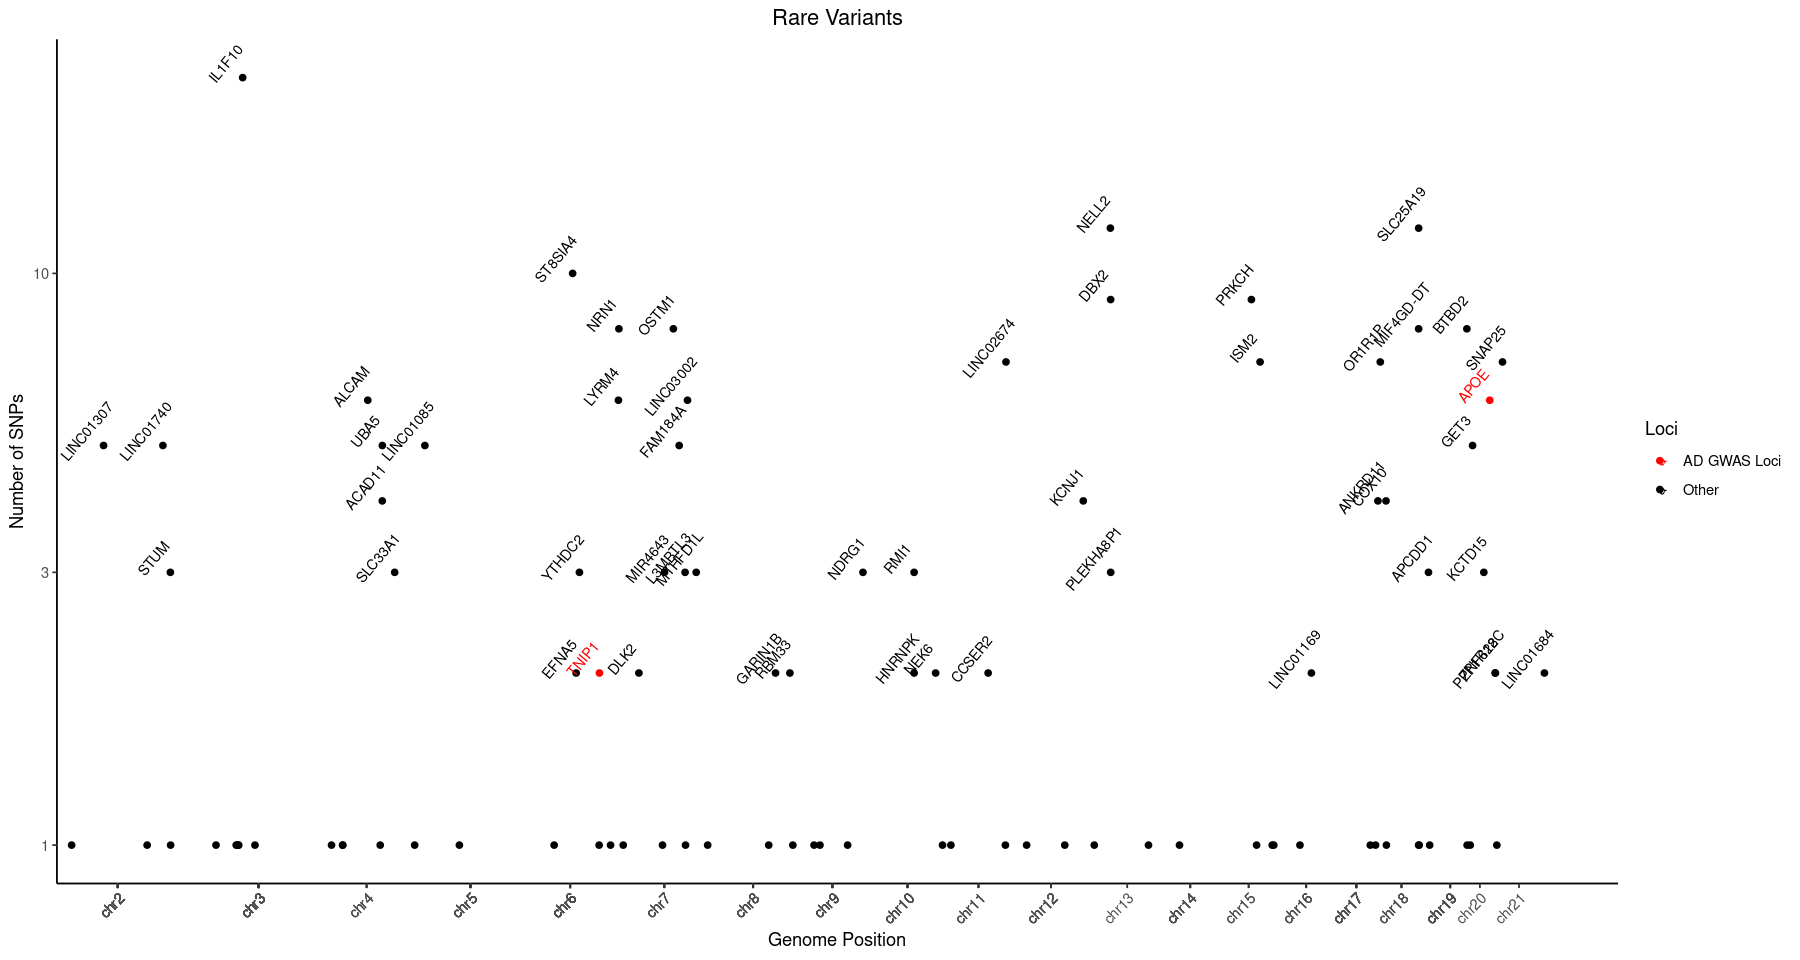

In [3]:
# Read the CSV file
snps <- read.csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv')
snps<-snps[snps$Contributor =="Win" | snps$Contributor =="Dmitry",]


# Load necessary libraries
library(BSgenome.Hsapiens.UCSC.hg38)
library(tidyverse)


# Remove duplicates
snps <- snps[!duplicated(snps), ]

# Calculate the number of SNPs near each gene
snps <- snps %>%
  group_by(nearest_gene,CHROM) %>%
  summarise(
    COUNT = n(),
    .groups = "drop"
  )
  
#sort by chromosome
snps <- snps %>%
  arrange(CHROM)
  
library(biomaRt)

# Use the ensembl dataset
ensembl <- useMart("ensembl",dataset="hsapiens_gene_ensembl")

# Assuming the 'nearest_gene' column contains gene symbols:
gene_symbols <- unique(snps$nearest_gene)

# Get the gene positions
gene_positions <- getBM(attributes=c('hgnc_symbol', 'chromosome_name', 'start_position', 'end_position'),
                        filters = 'hgnc_symbol',
                        values = gene_symbols,
                        mart = ensembl)

# You may want to create a single "position" column
gene_positions$position <- paste(gene_positions$chromosome_name, gene_positions$start_position, gene_positions$end_position, sep=":")

# Merge 'snps' and 'gene_positions'
snps <- merge(snps, gene_positions, by.x = "nearest_gene", by.y = "hgnc_symbol", all.x = TRUE)

# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]

# Calculate the cumulative chromosome lengths
cumulative_lengths <- cumsum(as.numeric(chromosome_lengths))

# Create the continuous genome position
#snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM] - chromosome_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]

#sort by chromosome
snps <- snps %>%
  arrange(CHROM)

#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Get the chromosome lengths
chromosome_lengths <- seqlengths(Hsapiens)

# Filter for the chromosomes 1:22
chromosome_lengths <- chromosome_lengths[paste0("chr", 1:22)]
nm<- names(chromosome_lengths)
# Convert the chromosome lengths to numeric to avoid integer overflow
chromosome_lengths <- as.numeric(chromosome_lengths)

# Calculate the cumulative chromosome lengths
cumulative_lengths <- c(0, cumsum(chromosome_lengths)[-length(chromosome_lengths)])

# Convert the cumulative lengths to named vector
names(cumulative_lengths) <- nm
names(chromosome_lengths) <- nm
# Now the cumulative_lengths is in the same format as seqlengths(Hsapiens)

# Create the continuous genome position
snps$genome_position <- snps$start_position + cumulative_lengths[snps$CHROM]

# Calculate the midpoints of each chromosome for labeling
chromosome_midpoints <- (cumulative_lengths - chromosome_lengths/2)[snps$CHROM]



# List of genes to highlight
highlight_genes <- unique(read.csv('/media/zihengc/T7 Shield/mpra3_lib_analysis/Find_nearest_gene/AD_GWAS_Gene_Wightman.csv')$Gene)

# Create a new variable for color
snps$Loci <- ifelse(snps$nearest_gene %in% highlight_genes, "AD GWAS Loci", "Other")

# Modify the plot code
p <- ggplot(snps, aes(x = genome_position, y = COUNT, label = nearest_gene, color = Loci)) +
  geom_point() +
  geom_text(data = subset(snps, COUNT > 1), vjust = -1.5, angle = 50, size = 3) +
  scale_y_continuous(trans = "log10") +
  scale_x_continuous(breaks = chromosome_midpoints, labels = names(chromosome_midpoints), expand = expansion(mult = c(0.01, 0.05))) + # expand x-axis
  scale_color_manual(values = c("AD GWAS Loci" = "red", "Other" = "black")) +
  labs(x = "Genome Position", y = "Number of SNPs") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),plot.title = element_text(hjust = 0.5))+
  ggtitle("Rare Variants") 
# Increase the width of the plot window
options(repr.plot.width=15, repr.plot.height=8)

print(p)

In [28]:
import pandas as pd
df = pd.read_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv',index_col=0)[["CHROM","SNPSTART","SNPEND","GENOME"]]
df[df["GENOME"] == "hg38"][["CHROM","SNPSTART","SNPEND"]].sort_values(["CHROM","SNPSTART","SNPEND"]).to_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_hg38.bed',sep=',',index=False,header=True)
df[df["GENOME"] == "hg19"][["CHROM","SNPSTART","SNPEND"]].sort_values(["CHROM","SNPSTART","SNPEND"]).to_csv('/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_hg19.bed',sep=',',index=False,header=True)

ERROR: Error in parse(text = x, srcfile = src): <text>:1:8: unexpected symbol
1: import pandas
           ^


In [7]:
head(bed)

,CHROM,SNPSTART,SNPEND
,<chr>,<int>,<int>
1,chr1,20852093,20852094
2,chr1,41782298,41782299
3,chr1,101453798,101453799
4,chr1,101453822,101453823
5,chr1,101453934,101453935
6,chr1,101454017,101454018


In [22]:
library(VariantAnnotation)
library(GenomicFeatures)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(GenomicRanges)
bed_file <- '/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_hg38.bed'
bed <- read.table(bed_file, header =TRUE, sep = ",")

# Create a GRanges object from the BED file
gr <- GRanges(
    seqnames = bed$CHROM,
    IRanges(
        start = bed$SNPSTART,
        end = bed$SNPEND
    ),
    SNP = bed$snp_id
)

library(annotatr)
annotations <- build_annotations(genome = 'hg38', annotations = c( 'hg38_basicgenes', 'hg38_genes_intergenic',
    'hg38_genes_intronexonboundaries'))
annotated_snps <- annotate_regions(regions = gr, annotations = annotations,ignore.strand = TRUE)
write.csv(data.frame(annotated_snps),'/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_genicAnnotation_hg38.csv')

'select()' returned 1:1 mapping between keys and columns

Building promoters...

Building 1to5kb upstream of TSS...

Building intergenic...

Building 5UTRs...

Building 3UTRs...

Building exons...

Building introns...

Building intron exon boundaries...

Annotating...



In [23]:
library(VariantAnnotation)
library(GenomicFeatures)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(GenomicRanges)
bed_file <- '/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_hg19.bed'
bed <- read.table(bed_file, header =TRUE, sep = ",")
# Create a GRanges object from the BED file
gr <- GRanges(
    seqnames = bed$CHROM,
    IRanges(
        start = bed$SNPSTART,
        end = bed$SNPEND
    ),
    SNP = bed$snp_id
)

library(annotatr)
annotations <- build_annotations(genome = 'hg19', annotations = c( 'hg19_basicgenes', 'hg19_genes_intergenic',
    'hg19_genes_intronexonboundaries'))
annotated_snps <- annotate_regions(regions = gr, annotations = annotations,ignore.strand = TRUE)
write.csv(data.frame(annotated_snps),'/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs_genicAnnotation_hg19.csv')

'select()' returned 1:1 mapping between keys and columns

Building promoters...

Building 1to5kb upstream of TSS...

Building intergenic...

Building 5UTRs...

Building 3UTRs...

Building exons...

Building introns...

Building intron exon boundaries...

Annotating...



In [1]:
#Add nearest gene to AD_MPRA_2_7_Contributor_20230213_unique.csv
import pandas as pd
df1 = pd.read_csv("/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/AD_MPRA_2_7_Contributor_20230213_unique.csv",index_col=0)
df2 = pd.read_csv("/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/MPRA_sequences - all 2022.2.7_contributor_GeneName_uniqueSNPs.csv",index_col=0)
df1 = df1.merge(df2[["RSID", "nearest_gene"]], on="RSID", how="left")
df1.to_csv("/media/zihengc/T7 Shield/mpra/MPRA_design/Get_sequences/Barcoding/2022.2.7 AD_MPRA_FINAL_INDELCORRECT/AD_MPRA_2_7/AD_MPRA_2_7_Contributor_20230213_unique_GeneName.csv")